# Estado do Conhecimento

**Mediação pedagógica e linguística entre docentes e tradutores-intérpretes de Libras/Português na Educação Profissional e Tecnológica**

Este caderno documenta e executa o levantamento do estado do conhecimento que fundamenta a
seção 1.1 do projeto de pesquisa. Nele estão reunidos os critérios de seleção, as regras de
triagem temática, o percurso que conduz dos registros brutos ao corpus final e os limites do
que o levantamento autoriza afirmar. O caderno é, ao mesmo tempo, o instrumento que produz os
quantitativos e o documento que descreve como foram produzidos, de modo que ambos permaneçam
sob a mesma revisão.

O estado do conhecimento é compreendido como processo de identificação, registro e categorização
da produção acadêmica em um campo delimitado, por meio do qual se procura reconhecer ênfases,
aproximações, recorrências e questões ainda abertas (Morosini; Fernandes, 2014). Não se
reivindica o estatuto de revisão sistemática. Assumem-se, contudo, compromissos de transparência
quanto à delimitação do corpus, à explicitação dos critérios e à rastreabilidade das decisões
analíticas.

O levantamento compreende teses e dissertações defendidas entre 2020 e 2025 e recuperadas, em
buscas realizadas em 2026, na Biblioteca Digital Brasileira de Teses e Dissertações (BDTD/IBICT)
e no Catálogo de Teses e Dissertações da CAPES. A delimitação a trabalhos nacionais decorre do
próprio problema investigado, que depende de uma configuração institucional brasileira: a
Educação Profissional e Tecnológica, as políticas de inclusão, a organização do trabalho docente
e a atuação de tradutores-intérpretes de Libras/Português.

## 1 Delimitação e estatuto das evidências

A triagem realizada neste caderno é **cartográfica**, e não interpretativa. A regra de termos
localiza em que registros um tema se encontra declarado; não estabelece o que cada trabalho
sustenta. Dessa distinção decorre o alcance das afirmações possíveis: os quantitativos descrevem
a distribuição da produção no campo delimitado e não autorizam, isoladamente, juízos sobre
método, resultados, limites ou originalidade de qualquer trabalho.

Assumem-se três níveis de sustentação, aos quais toda afirmação do levantamento remete
explicitamente. Os **metadados bibliográficos** descrevem autoria, ano, instituição, tipo
documental e origem. O **título, as palavras-chave e o resumo** sustentam a triagem e a
aproximação exploratória, sem equivaler à leitura integral. A **leitura dirigida registrada**,
por fim, é a única base admissível para contrastes qualitativos, para o exame de limites de cada
trabalho e para qualquer alegação de originalidade relativa.

**Separação entre selecionar e descrever.** Um critério decide o que integra o corpus; os eixos
temáticos descrevem o que nele foi reunido. As duas operações são mantidas distintas de modo
deliberado: quando a classificação temática também define a fronteira do levantamento, essa
fronteira deixa de poder ser justificada por si mesma. Aqui, a pertinência ao campo é
estabelecida por um núcleo temático único (seção 3), e os cinco eixos incidem apenas sobre os
trabalhos já selecionados.

**Não excludência dos eixos.** Os eixos são dimensões heurísticas de uma mesma problemática, e
não uma taxonomia de assuntos. Um mesmo trabalho produz mais de uma incidência, razão pela qual
a soma das incidências não corresponde ao tamanho do corpus e nenhum eixo isolado mede
proximidade com o objeto desta pesquisa.

## 2 Fontes e preparação dos dados

O caderno opera sobre um único arquivo, `arte4.xlsx`, organizado em três abas. A aba
`registros_originais` conserva os 2.636 registros recuperados nas buscas, com o identificador,
o título, o ano e a base de procedência, que são os campos de que dependem a separação das
referências complementares e a unificação de repetições. A aba `busca_log` registra as consultas realizadas.
A aba `dados` reúne os registros bibliográficos após a unificação, com os campos necessários à
triagem e à localização dos documentos.

A aba `registros_originais` conserva ainda o número de campos preenchidos em cada registro tal
como exportado, valor de que depende a escolha do representante de cada grupo de repetições. As
demais colunas da exportação não são mobilizadas pela análise e não foram conservadas.

Nenhum resultado é gravado. Indicadores, incidências temáticas, percurso de seleção e quadros
descritivos são reconstruídos em memória a cada execução e aparecem nas saídas das células. A
execução do caderno é, portanto, um ato de leitura e conferência, e não de edição da base.

In [1]:
from pathlib import Path
import hashlib
import re
import unicodedata
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", message="Workbook contains no default style")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.max_rows", 200)

# ── Parâmetros do levantamento ───────────────────────────────────────────────
ANO_INICIAL, ANO_FINAL = 2020, 2025
ANO_DAS_BUSCAS = 2026
SEMENTE = 20260908          # fixa a amostra de validação, tornando-a reproduzível
TAMANHO_DA_AMOSTRA = 120
ORDEM_DADOS_SHA256 = "e21ba2f8a1bf61677cb364bea1897a10ba6a8891bced56308f736691842766c4"

# Campos textuais em que a evidência é procurada. Retirar "resumo" torna a triagem
# mais restritiva, exigindo que o trabalho declare o tema em título ou palavras-chave.
CAMPOS_DE_EVIDENCIA = ["titulo_completo", "palavras_chave", "resumo"]

DIR = Path.cwd() if (Path.cwd() / "arte4.xlsx").is_file() else Path.cwd() / "notebooks"
ARQ_BASE = DIR / "arte4.xlsx"

# A aba `registros_originais` conserva os rótulos de exportação das bases; aqui são
# traduzidos para os nomes usados na aba de trabalho, sem alteração de conteúdo.
COLUNAS_DA_FONTE = {
    "ID": "identificador", "Título": "titulo_completo", "Ano": "ano_defesa",
    "Fonte/Base de Dados": "fonte_original",
}

# Correções de registro na fonte, declaradas individualmente. O título exportado para
# o registro 16756261 pertence a outro trabalho: as palavras-chave, o resumo e o PDF
# depositado confirmam o título aqui adotado.
CORRECOES_DE_REGISTRO = {
    "16756261": {
        "titulo_completo": "Elaboração de recursos educacionais para acessibilidade "
                           "na educação ambiental do estudante surdo",
    },
}

# Representantes de grupo conservados na aba de trabalho que a regra de completude não
# elegeria. Tratam-se dos mesmos trabalhos, recuperados em duas bases: a escolha entre
# eles não altera o corpus, e fica declarada para que a conferência permaneça estrita.
REPRESENTANTES_DECLARADOS = {"13202400"}

# Resumos reconstruídos por extração automática do PDF depositado, onde a exportação
# das bases entregou apenas a nota de rosto ou um fragmento. O texto passa a ser mais
# fiel ao trabalho, mas sua procedência é a extração, e não a base: por isso é contado
# à parte no quadro de edições.
RESUMOS_EXTRAIDOS_DE_PDF = {
    "11270332",
    "11315899",
    "12875790",
    "UFOP_62f703f36be73d94aa7f3611aaf3ff6a",
    "UFOP_71866bf0d5b23b1cbabadad00514e0ab",
    "UFOP_7766208ee565eeed52f351f03dd7bc3c",
    "UFPE_e7fa2a9bf5f5a91c642b50e600bda945",
    "UNB_e32eb082b9711e8c6e7c382019128393",
    "UTFPR-12_07e13241b41915566b270bd91480eb65",
    "bdtd_000023",
    "bdtd_000175",
    "bdtd_000181",
    "bdtd_000195",
    "bdtd_000202",
    "bdtd_000210",
    "bdtd_000216",
    "bdtd_000278",
    "bdtd_000340",
    "bdtd_000350",
    "bdtd_000494",
    "bdtd_000519",
    "bdtd_000537",
    "bdtd_000552",
    "bdtd_000561",
}

ler_aba = lambda aba: pd.read_excel(ARQ_BASE, sheet_name=aba, dtype=str).replace("", pd.NA)

bruto = ler_aba("registros_originais").rename(columns=COLUNAS_DA_FONTE)
for identificador, campos in CORRECOES_DE_REGISTRO.items():
    for campo, valor in campos.items():
        bruto.loc[bruto["identificador"].astype(str) == identificador, campo] = valor
busca_log = pd.read_excel(ARQ_BASE, sheet_name="busca_log")
dados = ler_aba("dados")

# A amostra com semente fixa depende também da ordem das linhas. Este hash faz a
# execução falhar de modo explícito se a aba for reordenada no Excel.
ordem_dados_sha256 = hashlib.sha256(
    "".join(dados["identificador"].fillna("").astype(str)).encode("utf-8")
).hexdigest()
assert ordem_dados_sha256 == ORDEM_DADOS_SHA256, (
    "a ordem da aba dados mudou; a amostra de validação precisa ser reproduzida "
    "ou a alteração, conferida e documentada antes de atualizar o hash"
)

display(Markdown(
    f"Registros preservados em `{ARQ_BASE.name}`, aba `registros_originais`: **{len(bruto):,}**  ·  "
    f"registros bibliográficos na aba `dados`: **{len(dados):,}**".replace(",", ".")
))

Registros preservados em `arte4.xlsx`. aba `registros_originais`: **2.636**  ·  registros bibliográficos na aba `dados`: **2.420**

In [2]:
def normalizar(texto) -> str:
    """Caixa baixa, sem acentuação e sem pontuação, para comparação de termos."""
    t = unicodedata.normalize("NFKD", str(texto))
    t = "".join(c for c in t if not unicodedata.combining(c)).lower()
    return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9]+", " ", t)).strip()


def texto_de_evidencia(df: pd.DataFrame, campos=None) -> pd.Series:
    """Concatena e normaliza os campos em que os termos são procurados."""
    campos = campos or CAMPOS_DE_EVIDENCIA
    junto = df[campos[0]].fillna("")
    for c in campos[1:]:
        junto = junto + " " + df[c].fillna("")
    return junto.map(normalizar)


def contem(texto: pd.Series, termos: list[str]) -> pd.Series:
    """Verdadeiro onde ao menos um dos termos ocorre no texto normalizado."""
    padrao = "|".join(re.escape(normalizar(t)) for t in termos)
    return texto.str.contains(padrao, regex=True, na=False)


def referencia_complementar(ids: pd.Series) -> pd.Series:
    """Registros com prefixo CC_ integram a fundamentação, não as buscas."""
    return ids.astype(str).str.startswith("CC_")


def atribuir_base(df: pd.DataFrame) -> pd.Series:
    """Origem de cada registro, recuperada do prefixo quando o campo está vazio.

    O identificador guarda a busca de procedência (`bdtd_search_`, `bdtd_`), de modo
    que a atribuição é derivável por regra mesmo onde o rótulo não foi preenchido.
    """
    fonte = df["fonte_original"].fillna("")
    ids = df["identificador"].astype(str)
    capes, bdtd = fonte.str.contains("CAPES"), fonte.str.contains("BDTD")

    atribuida = pd.Series(pd.NA, index=df.index, dtype="object")
    atribuida[capes] = "Catálogo de Teses e Dissertações da CAPES"
    atribuida[bdtd] = "BDTD/IBICT"
    atribuida[capes & bdtd] = "Ambas as bases"
    atribuida[atribuida.isna() & ids.str.startswith("bdtd")] = "BDTD/IBICT"
    atribuida[referencia_complementar(ids)] = "Referência complementar"
    return atribuida


def impressao(texto) -> str | None:
    """Doze dígitos de SHA-256 sobre o texto com espaços normalizados.

    Permite detectar alteração de `resumo` e `palavras_chave` na aba de trabalho
    sem conservar uma segunda cópia desses campos.
    """
    if pd.isna(texto) or not str(texto).strip():
        return None
    return hashlib.sha256(re.sub(r"\s+", " ", str(texto)).strip().encode("utf-8")).hexdigest()[:12]


EVIDENCIA = texto_de_evidencia(dados)
display(Markdown(
    "Campos de evidência: " + ", ".join(f"`{c}`" for c in CAMPOS_DE_EVIDENCIA)
    + f" · extensão mediana do texto examinado: **{int(EVIDENCIA.str.len().median())}** caracteres."
))

Campos de evidência: `titulo_completo`, `palavras_chave`, `resumo` · extensão mediana do texto examinado: **2422** caracteres.

### Registro das consultas

O levantamento apoiou-se em consultas a bases de teses e dissertações, a bases de artigos
científicos e a repositórios institucionais de Institutos Federais e de programas do ProfEPT,
cujo registro consta do quadro a seguir. A recuperação em repositórios institucionais foi
conduzida diretamente nos sítios das instituições.

A atribuição de origem recuperável registro a registro distingue, contudo, apenas duas
procedências, e é essa atribuição que o quadro seguinte reproduz. Os registros obtidos
diretamente em repositórios institucionais foram incorporados sob a identificação da BDTD, não
sendo distinguíveis *a posteriori*. As consultas a bases de artigos serviram à fundamentação
teórica: o corpus cartográfico retém apenas teses e dissertações, por força do critério C5.

Onde o campo de origem não foi preenchido, a base é recuperada do prefixo do identificador, que
registra a busca de procedência. Nenhum registro permanece sem atribuição.

As expressões de busca reproduzidas foram reconstruídas e as datas exatas das consultas não
foram preservadas, de modo que não se reivindica reprodução literal em nova execução.

In [3]:
display(Markdown("**Consultas registradas.**"))
consulta_exibida = busca_log[["base", "string_busca", "data_busca", "filtros", "n_resultados", "n_elegiveis"]].copy()
bases_sem_incorporacao = {"SciELO", "ERIC", "DOAJ", "Redalyc", "Dialnet"}
consulta_exibida["n_incorporados"] = pd.NA
consulta_exibida.loc[consulta_exibida["base"].isin(bases_sem_incorporacao), "n_incorporados"] = 0
display(consulta_exibida)
display(Markdown(
    "`n_resultados` e `n_elegiveis` descrevem cada consulta registrada. A coluna "
    "`n_incorporados` explicita as cinco consultas que não contribuíram com registros. "
    "Nas outras duas linhas, o valor permanece ausente porque a base preservada permite "
    "atribuir CAPES ou BDTD, mas não reconstruir com segurança a consulta individual de origem."
))

bruto["base_atribuida"] = atribuir_base(bruto)
atribuicao = (bruto["base_atribuida"].value_counts()
              .rename_axis("Procedência recuperável").reset_index(name="Registros"))
display(Markdown("**Procedência efetivamente registrada nos dados.**"))
display(atribuicao)

sem_atribuicao = int(bruto["base_atribuida"].isna().sum())
assert sem_atribuicao == 0, "há registros sem procedência recuperável"
display(Markdown(
    f"Registros sem procedência recuperável: **{sem_atribuicao}**. "
    f"Dos registros de busca, **{int((bruto['fonte_original'].isna() & ~referencia_complementar(bruto['identificador'])).sum())}** "
    f"tiveram a base recuperada pelo prefixo do identificador."
))

**Consultas registradas.**

,base,string_busca,data_busca,filtros,n_resultados,n_elegiveis,n_incorporados
0,Portal CAPES,(surdo OR surdos OR surdez OR Libras) AND (intérprete OR TILSP OR planejamento conjunto OR mediação pedagó...,2026-09-05,Período: 2020-2026; Tipo: Dissertação/Tese,1250,410,<NA>
1,SciELO,(Libras) AND (educação OR ensino OR inclusão),2026-09-05,Período: 2020-2026,340,85,0
2,ERIC,(deaf OR sign language) AND (teacher OR interpreter OR planning),2026-09-05,Peer reviewed,410,62,0
3,DOAJ,(Libras) AND (educação de surdos),2026-09-05,Open access,190,45,0
4,Redalyc,(Libras) AND (interpretacion OR educacion),2026-09-05,Artigos,120,28,0
5,Dialnet,(Libras) AND (surdos),2026-09-05,Artigos/Teses,95,18,0
6,Repositórios IFs / ProfEPT,(Libras) AND (EPT OR instituto federal) AND (intérprete OR planejamento),2026-09-05,Repositórios institucionais ProfEPT/IFs,280,115,<NA>


`n_resultados` e `n_elegiveis` descrevem cada consulta registrada. A coluna `n_incorporados` explicita as cinco consultas que não contribuíram com registros. Nas outras duas linhas, o valor permanece ausente porque a base preservada permite atribuir CAPES ou BDTD, mas não reconstruir com segurança a consulta individual de origem.

**Procedência efetivamente registrada nos dados.**

,Procedência recuperável,Registros
0,Catálogo de Teses e Dissertações da CAPES,1820
1,BDTD/IBICT,798
2,Referência complementar,18


Registros sem procedência recuperável: **0**. Dos registros de busca, **105** tiveram a base recuperada pelo prefixo do identificador.

### Edições posteriores à exportação

A aba de trabalho admite completar campos que as bases entregaram vazios, sobretudo o resumo,
de que dependem a pertinência ao campo e as duas camadas de eixos. Para que essas edições não
fiquem invisíveis, a aba `registros_originais` conserva a impressão digital do resumo e das
palavras-chave tal como exportados.

Três situações são contadas separadamente, porque têm naturezas distintas. **Completar** um
campo vazio é curadoria e amplia o alcance da triagem. **Alterar** um campo já preenchido, quando
o registro pertence a um grupo de repetições, decorre da própria unificação: o registro
conservado incorpora os metadados da outra base, e o conteúdo diverge do que constava sob aquele
identificador. Alteração **fora** de grupo de repetição não tem essa explicação e exige exame.

In [4]:
original = ler_aba("registros_originais").set_index("ID")
ids = dados["identificador"].astype(str)

# Pertencimento a grupo de repetição, calculado aqui a partir dos registros originais:
# é a chave para distinguir alteração herdada da unificação de alteração posterior.
_buscas = bruto.loc[~referencia_complementar(bruto["identificador"])]
_chave = (_buscas["titulo_completo"].map(normalizar) + "|"
          + pd.to_numeric(_buscas["ano_defesa"], errors="coerce").astype("Int64").astype(str))
em_grupo_de_repeticao = ids.isin(
    _buscas.loc[_chave.duplicated(keep=False), "identificador"].astype(str)
)

edicoes = []
for campo, coluna in [("resumo", "resumo_impressao"), ("palavras_chave", "palavras_chave_impressao")]:
    exportado = ids.map(original[coluna])
    atual = dados[campo].map(impressao)
    alterado = exportado.notna() & atual.notna() & (exportado != atual)
    extraido = ids.isin(RESUMOS_EXTRAIDOS_DE_PDF) if campo == "resumo" else pd.Series(False, index=ids.index)
    edicoes.append({
        "Campo": campo,
        "Completado": int((exportado.isna() & atual.notna() & ~extraido).sum()),
        "Reconstruído do PDF": int((atual.notna() & extraido).sum()),
        "Alterado em grupo de repetição": int((alterado & em_grupo_de_repeticao & ~extraido).sum()),
        "Alterado fora de grupo": int((alterado & ~em_grupo_de_repeticao & ~extraido).sum()),
        "Esvaziado": int((exportado.notna() & atual.isna()).sum()),
    })
quadro_edicoes = pd.DataFrame(edicoes)
display(quadro_edicoes)
display(Markdown(
    f"Campos completados após a exportação: **{int(quadro_edicoes['Completado'].sum())}**, "
    f"que ampliam a evidência disponível à triagem. Alterações atribuíveis à unificação de "
    f"repetições: **{int(quadro_edicoes['Alterado em grupo de repetição'].sum())}**. "
    f"Resumos reconstruídos por extração do PDF depositado: "
    f"**{int(quadro_edicoes['Reconstruído do PDF'].sum())}**. "
    f"Alterações fora de grupo de repetição, que exigem exame: "
    f"**{int(quadro_edicoes['Alterado fora de grupo'].sum())}**. Nenhum campo foi esvaziado."
))

,Campo,Completado,Reconstruído do PDF,Alterado em grupo de repetição,Alterado fora de grupo,Esvaziado
0,resumo,37,24,0,2,0
1,palavras_chave,2,0,62,0,0


Campos completados após a exportação: **39**, que ampliam a evidência disponível à triagem. Alterações atribuíveis à unificação de repetições: **62**. Resumos reconstruídos por extração do PDF depositado: **24**. Alterações fora de grupo de repetição, que exigem exame: **2**. Nenhum campo foi esvaziado.

### Descritores que orientaram a busca

A recuperação foi orientada por cinco conjuntos de descritores, organizados antes das consultas
como estratégia de localização de material. Ficam aqui registrados por rastreabilidade: eles
descrevem **onde se procurou**, e não como o corpus é analisado. A distinção importa, porque os
eixos da seção 5 derivam do problema de pesquisa, e não desta estratégia.

| Conjunto de descritores | Termos empregados na busca |
| --- | --- |
| Surdez | surdez · educação de surdos · educação bilíngue · Libras · *deaf education* · *bilingual education* |
| EPT | Educação Profissional e Tecnológica · EPT · ensino técnico · educação profissional · *vocational education* |
| Tecnologia | mediação tecnológica · tecnologia assistiva · software educacional · acessibilidade digital · *assistive technology* |
| Base teórica | Vygotsky · Teoria Histórico-Cultural · mediação · ZDP · Materialismo Histórico-Dialético · práxis |
| Inclusão e permanência | evasão · permanência · inclusão · trajetória escolar · acessibilidade pedagógica |

As consultas combinaram os conjuntos entre si, e não isoladamente, de modo a evitar resultados
genéricos: *surdez* com *EPT* e *permanência*; *Libras* com *software* e *educação profissional*;
*mediação tecnológica* com *surdo* e *inclusão*; *Vygotsky* com *surdez* e *software*.

O conjunto **Base teórica** orientou a recuperação de referências de fundamentação, incorporadas
como referências complementares (prefixo `CC_`) e mantidas fora do denominador do levantamento.

## 3 Critérios de inclusão e exclusão

Os critérios são cumulativos e observáveis, aplicados na ordem em que se apresentam. Cada um
opera sobre campos declarados e produz decisão reproduzível a partir do arquivo bruto.

**C1: origem.** Integram as buscas os registros recuperados na BDTD/IBICT e no Catálogo de
Teses e Dissertações da CAPES. Os registros identificados pelo prefixo `CC_` correspondem a
referências complementares mobilizadas na fundamentação e permanecem fora do denominador do
levantamento.

**C2: unificação de repetições.** Registros recuperados em ambas as bases são agrupados por
título normalizado e ano de defesa. Em cada grupo permanece o registro com metadados mais
completos. A regra é determinística e reproduzível; casos em que a proximidade dos títulos não
confirma tratar-se do mesmo trabalho permanecem separados e são registrados como tal.

**C3: metadados mínimos.** São exigidos título, autoria e ano identificáveis, sem os quais o
registro não sustenta descrição bibliográfica.

**C4: recorte temporal.** Trabalhos defendidos entre 2020 e 2025. O recorte acompanha o período
posterior à consolidação da Rede Federal como campo de pesquisa sobre inclusão e antecede o ano
das buscas.

**C5: tipo documental.** Teses e dissertações. Artigos, capítulos e demais tipos documentais
podem ser mobilizados na fundamentação, como referências complementares, mas não integram o
corpus cartográfico.

**C6: pertinência ao campo.** O registro apresenta, nos campos de evidência, ao menos um termo
do núcleo temático. O campo do levantamento é a educação de pessoas surdas, e é essa condição,
e não a classificação temática posterior, que estabelece a fronteira do corpus.

**Descarte por leitura.** Um registro que satisfaça C1 a C6 pode, ainda assim, ser excluído
quando a leitura de título e resumo mostrar que a ocorrência dos termos é enganosa. O descarte é
individual, justificado por escrito e assinado. Constitui a única exclusão não derivável por
regra e permanece identificável no percurso.

In [5]:
# ── Núcleo temático (C6) ─────────────────────────────────────────────────────
# Define o campo do levantamento. Os radicais alcançam as variações de gênero e
# número: "surd" recobre surdo, surda, surdos, surdas, surdez e surdocegueira.
NUCLEO_TEMATICO = [
    "surd", "libras", "lingua de sinais", "lingua brasileira de sinais",
    "educacao bilingue", "bilinguismo",
]

# ── Descartes por leitura ────────────────────────────────────────────────────
# Registros excluídos por decisão registrada, apesar de satisfazerem C1 a C6.
# Formato: identificador -> justificativa e responsável pela conferência.
DESCARTE_POR_LEITURA: dict[str, str] = {
    "11082210": "Letras/Libras aparece apenas como nome de curso em lista; tema ambiental. Conferência manual do autor, 10 set. 2026.",
    "11467001": "libras designa unidade de peso; tese epidemiológica sobre tabagismo. Conferência manual do autor, 10 set. 2026.",
    "11676593": "surdez aparece apenas no entorno familiar de criança autista; objeto alheio ao campo. Conferência manual do autor, 10 set. 2026.",
}

criterios = pd.DataFrame(
    [
        ("C1", "Origem", "BDTD/IBICT ou Catálogo CAPES; prefixo CC_ fora do denominador"),
        ("C2", "Unificação de repetições", "Título normalizado e ano de defesa coincidentes"),
        ("C3", "Metadados mínimos", "Título, autoria e ano identificáveis"),
        ("C4", "Recorte temporal", f"Defesa entre {ANO_INICIAL} e {ANO_FINAL}"),
        ("C5", "Tipo documental", "Tese ou dissertação"),
        ("C6", "Pertinência ao campo", "Ao menos um termo do núcleo temático nos campos de evidência"),
        ("-", "Descarte por leitura", "Decisão individual registrada, com justificativa assinada"),
    ],
    columns=["Critério", "Dimensão", "Regra operacional"],
)
display(criterios)
display(Markdown("**Núcleo temático:** " + " · ".join(f"`{t}`" for t in NUCLEO_TEMATICO)))

,Critério,Dimensão,Regra operacional
0,C1,Origem,BDTD/IBICT ou Catálogo CAPES; prefixo CC_ fora do denominador
1,C2,Unificação de repetições,Título normalizado e ano de defesa coincidentes
2,C3,Metadados mínimos,"Título, autoria e ano identificáveis"
3,C4,Recorte temporal,Defesa entre 2020 e 2025
4,C5,Tipo documental,Tese ou dissertação
5,C6,Pertinência ao campo,Ao menos um termo do núcleo temático nos campos de evidência
6,—,Descarte por leitura,"Decisão individual registrada, com justificativa assinada"


**Núcleo temático:** `surd` · `libras` · `lingua de sinais` · `lingua brasileira de sinais` · `educacao bilingue` · `bilinguismo`

## 4 Percurso de seleção

O percurso reconstrói, etapa a etapa, a passagem dos registros brutos ao corpus final. Cada
quantidade é derivada por código a partir do arquivo bruto, e as etapas precisam fechar entre si:
o percurso parte do total preservado, decresce a cada critério e termina no corpus. A figura é
empregada como recurso de transparência do fluxo, e não como reivindicação do estatuto de
revisão sistemática nos moldes PRISMA.

In [6]:
# ── C1: separação entre buscas e referências complementares ──────────────────
eh_cc = referencia_complementar(bruto["identificador"])
complementares, buscas = bruto[eh_cc], bruto[~eh_cc]

# ── C2: unificação determinística de repetições ──────────────────────────────
chave = (buscas["titulo_completo"].map(normalizar) + "|"
         + pd.to_numeric(buscas["ano_defesa"], errors="coerce").astype("Int64").astype(str))
em_grupo = chave.duplicated(keep=False)
repeticoes_removidas = int(em_grupo.sum()) - chave[em_grupo].nunique()

# Em cada grupo permanece o registro com metadados mais completos, conforme C2.
completude = pd.to_numeric(buscas["campos_preenchidos"], errors="coerce")
representantes = (buscas.assign(_chave=chave, _completude=completude)
                  .sort_values(["_chave", "_completude"], ascending=[True, False])
                  .drop_duplicates("_chave", keep="first"))

# A aba de trabalho é conferida por identidade, e não apenas por contagem: os mesmos
# grupos e os mesmos representantes, salvo empates de completude, em que a escolha
# entre registros igualmente preenchidos é indiferente.
assert set(chave) == set(
    dados["titulo_completo"].map(normalizar) + "|"
    + pd.to_numeric(dados["ano_defesa"], errors="coerce").astype("Int64").astype(str)
), "os grupos de repetição da aba de trabalho não correspondem aos registros originais"

divergentes = set(dados["identificador"].astype(str)) - set(representantes["identificador"].astype(str))
empates = {
    i for i in divergentes
    if completude[chave == chave[buscas["identificador"].astype(str) == i].iloc[0]].nunique() == 1
}
assert divergentes <= empates | REPRESENTANTES_DECLARADOS, \
    f"representantes divergentes sem empate nem declaração: {sorted(divergentes - empates - REPRESENTANTES_DECLARADOS)}"
display(Markdown(
    f"Unificação conferida por identidade: **{len(dados) - len(divergentes)}** representantes "
    f"reproduzidos pela regra de completude; **{len(empates)}** decorrem de empate, em que a "
    f"escolha entre registros igualmente preenchidos é indiferente; "
    f"**{len(divergentes - empates)}** estão declarados individualmente. Em todos os casos "
    f"trata-se do mesmo trabalho recuperado em duas bases, de modo que o corpus não se altera."
))

# ── C3 a C6 sobre os registros unificados ────────────────────────────────────
metadados_minimos = dados[["titulo_completo", "autores", "ano_defesa"]].notna().all(axis=1)
ano = pd.to_numeric(dados["ano_defesa"], errors="coerce")
no_periodo = ano.between(ANO_INICIAL, ANO_FINAL)
tipo_elegivel = dados["tipo_documental"].fillna("").str.lower().str.contains("tese|disserta", regex=True)
pertinente = contem(EVIDENCIA, NUCLEO_TEMATICO)
descartado = dados["identificador"].astype(str).isin(DESCARTE_POR_LEITURA)

selecionado = metadados_minimos & no_periodo & tipo_elegivel & pertinente & ~descartado
corpus = dados[selecionado].copy()

percurso = pd.DataFrame(
    [
        ("Registros preservados das bases", len(bruto), 0, "Ponto de partida"),
        ("C1 · Registros das buscas", len(buscas), len(complementares), "Referências complementares CC_ à parte"),
        ("C2 · Após unificação de repetições", len(dados), repeticoes_removidas, "Título normalizado e ano coincidentes"),
        ("C3 · Com metadados mínimos", int(metadados_minimos.sum()), int((~metadados_minimos).sum()), "Título, autoria e ano"),
        (f"C4 · Defendidos entre {ANO_INICIAL} e {ANO_FINAL}", int((metadados_minimos & no_periodo).sum()),
         int((metadados_minimos & ~no_periodo).sum()), "Ano de defesa no recorte"),
        ("C5 · Teses e dissertações", int((metadados_minimos & no_periodo & tipo_elegivel).sum()),
         int((metadados_minimos & no_periodo & ~tipo_elegivel).sum()), "Tipo documental elegível"),
        ("C6 · Pertinentes ao campo", int((metadados_minimos & no_periodo & tipo_elegivel & pertinente).sum()),
         int((metadados_minimos & no_periodo & tipo_elegivel & ~pertinente).sum()), "Núcleo temático nos campos de evidência"),
        ("Corpus final", len(corpus), int(descartado.sum()), "Após descartes por leitura"),
    ],
    columns=["Etapa", "Registros", "Retirados", "Justificativa"],
)

assert percurso["Registros"].is_monotonic_decreasing, "o percurso deve decrescer a cada etapa"
display(percurso)
display(Markdown(f"Corpus final do estado do conhecimento: **{len(corpus)}** teses e dissertações."))

Unificação conferida por identidade: **2417** representantes reproduzidos pela regra de completude; **2** decorrem de empate, em que a escolha entre registros igualmente preenchidos é indiferente; **1** estão declarados individualmente. Em todos os casos trata-se do mesmo trabalho recuperado em duas bases, de modo que o corpus não se altera.

,Etapa,Registros,Retirados,Justificativa
0,Registros preservados das bases,2636,0,Ponto de partida
1,C1 · Registros das buscas,2618,18,Referências complementares CC_ à parte
2,C2 · Após unificação de repetições,2420,198,Título normalizado e ano coincidentes
3,C3 · Com metadados mínimos,2420,0,"Título, autoria e ano"
4,C4 · Defendidos entre 2020 e 2025,2406,14,Ano de defesa no recorte
5,C5 · Teses e dissertações,2392,14,Tipo documental elegível
6,C6 · Pertinentes ao campo,1832,560,Núcleo temático nos campos de evidência
7,Corpus final,1829,3,Após descartes por leitura


Corpus final do estado do conhecimento: **1829** teses e dissertações.

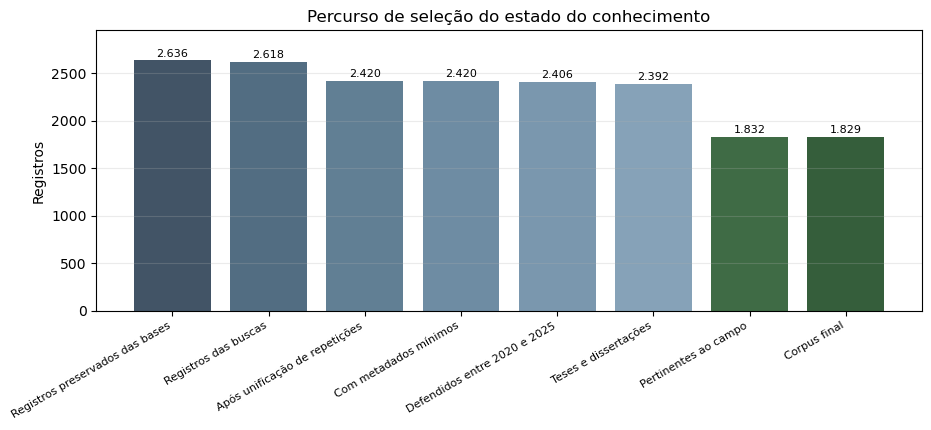

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
cores = ["#425466", "#526D82", "#617F94", "#6E8CA3", "#7A97AE", "#86A2B8", "#3F6B45", "#355E3B"]
ax.bar(range(len(percurso)), percurso["Registros"], color=cores)
ax.set_xticks(range(len(percurso)))
ax.set_xticklabels([e.split(" · ")[-1] for e in percurso["Etapa"]], rotation=30, ha="right", fontsize=8)
for i, v in enumerate(percurso["Registros"]):
    ax.text(i, v + max(percurso["Registros"]) * 0.015, f"{v:,}".replace(",", "."), ha="center", fontsize=8)
ax.set_title("Percurso de seleção do estado do conhecimento")
ax.set_ylabel("Registros")
ax.grid(axis="y", alpha=0.25)
ax.set_ylim(0, max(percurso["Registros"]) * 1.12)
plt.tight_layout()
plt.show()

## 5 Eixos temáticos e dimensões de proximidade

A leitura do corpus organiza-se em duas camadas, com funções distintas e deliberadamente
separadas. A primeira **descreve o campo**: indica onde a produção brasileira se situa, e sua
função é cartográfica. A segunda **mede a aderência ao objeto**: verifica quantas das dimensões
enunciadas na hipótese analítica deste projeto cada trabalho reúne, e sua função é localizar,
dentro do corpus amplo, o núcleo que exige leitura integral.

Reunir as duas funções em um único conjunto de eixos produziria, em qualquer direção, um
resultado inútil. Eixos suficientemente amplos para descrever o campo não discriminam
proximidade; eixos estreitos o bastante para medir aderência deixam a maior parte do corpus sem
classificação. A separação preserva as duas leituras. Ela é funcional, não lexical: alguns
termos aparecem nas duas camadas porque a mesma evidência pode descrever o campo e, sob outra
pergunta, indicar aderência ao objeto. Em particular, `EPT` e `EPT e Rede Federal` usam o mesmo
vocabulário. Na cartografia, ele mede incidência temática; na proximidade, vale uma entre cinco
condições e não basta, isoladamente, para levar um trabalho ao corte de três dimensões. Termos
como `glossari`, `sinalari`, `dicionari`, `napne` e `profept` também se repetem quando cumprem
funções analíticas distintas. Essa não exclusividade exige leitura posterior dos candidatos.

### Camada 1: eixos cartográficos

Descrevem a distribuição temática da produção. Herdam a estrutura dos conjuntos de descritores
que orientaram a busca (seção 2), convertida em categorias de incidência.

**Ensino e aprendizagem de surdos** reúne os trabalhos centrados em processos de escolarização,
currículo, didática, alfabetização e letramento. **Formação e atuação profissional** recobre a
formação e o exercício de docentes e tradutores-intérpretes. **Tecnologia e recursos** abrange
software, plataformas, materiais didáticos e registros terminológicos. **Inclusão, permanência e
política** compreende políticas educacionais, acessibilidade, barreiras, evasão e trajetória
escolar. **EPT e Rede Federal** situa os trabalhos no contexto da Educação Profissional e
Tecnológica.

Nenhum desses eixos afirma o que o trabalho sustenta: registram em que região do campo ele se
inscreve.

### Camada 2: dimensões de proximidade ao objeto

Derivam, uma a uma, da hipótese analítica enunciada no projeto, segundo a qual a mediação
investigada "se organiza pela articulação entre condições materiais de trabalho, intencionalidade
pedagógica compartilhada e preparação linguística dos conceitos técnico-científicos".

| Dimensão | Enunciado do projeto de que deriva |
| --- | --- |
| Mediação conceitual | "preparação linguística dos conceitos técnico-científicos" |
| Planejamento conjunto | "intencionalidade pedagógica compartilhada"; "práticas de planejamento conjunto entre docentes e TILSP" |
| Condições institucionais | "condições materiais de trabalho"; "condições institucionais, materiais, pedagógicas e linguísticas" |
| Registro bilíngue | "proposição de um Ambiente Bilíngue de Mediação Conceitual (Português/Libras)" |
| EPT | "Instituto Federal de Goiás – Câmpus Aparecida de Goiânia"; contexto da Educação Profissional e Tecnológica |

O número de dimensões que um trabalho reúne estratifica o corpus por aderência. Trabalhos que
reúnem três ou mais constituem os **candidatos ao núcleo de leitura integral**; os que reúnem
duas formam a camada de contraste. A regra **indica** esses trabalhos, não os estabelece: a
composição do núcleo depende de leitura, e a indicação é ponto de partida para ela.

In [8]:
# ── Camada 1: eixos cartográficos ────────────────────────────────────────────
EIXOS_CARTOGRAFICOS = {
    "Ensino e aprendizagem de surdos": [
        "ensino", "aprendizagem", "aprendizado", "escolarizacao", "curriculo",
        "didatic", "alfabetizacao", "letramento", "leitura e escrita",
    ],
    "Formação e atuação profissional": [
        "professor", "docente", "interprete", "tradutor", "tilsp",
        "formacao", "atuacao profissional",
    ],
    "Tecnologia e recursos": [
        "tecnolog", "software", "aplicativ", "plataforma", "digital",
        "recurso didatic", "material didatic", "video", "glossari", "sinalari", "dicionari",
    ],
    "Inclusão, permanência e política": [
        "inclus", "permanencia", "evasao", "trajetoria escolar", "politic",
        "acessibilidade", "legislac", "direito", "barreira",
    ],
    "EPT e Rede Federal": [
        "educacao profissional", "ensino tecnic", "curso tecnic", "ensino medio integrado",
        "instituto federal", "rede federal", "cefet", "napne", "profept",
    ],
}

# ── Camada 2: dimensões da hipótese analítica ────────────────────────────────
DIMENSOES_DE_PROXIMIDADE = {
    # "preparação linguística dos conceitos técnico-científicos"
    "Mediação conceitual": [
        "mediacao conceitual", "mediacao pedagogica", "mediacao linguistica",
        "mapa conceitual", "mapas conceituais", "mapeamento conceitual", "rede conceitual",
        "conceito cientific", "conceitos cientific", "conceito tecnic", "conceitos tecnic",
        "termo tecnic", "termos tecnic", "terminolog", "sinal termo", "sinais termo",
        "vocabulario tecnic", "lexic",
    ],
    # "intencionalidade pedagógica compartilhada"; "planejamento conjunto"
    "Planejamento conjunto": [
        "planejamento conjunto", "planejamento articulad", "planejamento participativ",
        "colaborativ", "colaborac", "cooperativ", "codocencia", "co docencia", "bidocencia",
        "coensino", "atuacao conjunta", "trabalho conjunto", "professor interprete",
        "docente e interprete", "professor e interprete", "parceria",
    ],
    # "condições materiais de trabalho"; "condições institucionais"
    "Condições institucionais": [
        "condicoes de trabalho", "condicoes institucionais", "condicoes de atuacao",
        "carga horaria", "jornada de trabalho", "remuneracao", "valorizacao profissional",
        "napne", "nucleo de acessibilidade", "organizacao do trabalho", "precarizacao",
        "apoio institucional",
    ],
    # "Ambiente Bilíngue de Mediação Conceitual (Português/Libras)"
    "Registro bilíngue": [
        "glossari", "sinalari", "dicionari", "repositorio de sinais", "banco de sinais",
        "material bilingue", "videoaula", "video em libras", "ferramenta colaborativa",
        "recurso educacional", "recursos educacionais",
    ],
    # contexto da Educação Profissional e Tecnológica
    "EPT": [
        "educacao profissional", "ensino tecnic", "curso tecnic", "ensino medio integrado",
        "instituto federal", "rede federal", "cefet", "napne", "profept",
    ],
}

evidencia_corpus = texto_de_evidencia(corpus)
cartografia = pd.DataFrame(
    {e: contem(evidencia_corpus, t) for e, t in EIXOS_CARTOGRAFICOS.items()}, index=corpus.index
)
proximidade = pd.DataFrame(
    {d: contem(evidencia_corpus, t) for d, t in DIMENSOES_DE_PROXIMIDADE.items()}, index=corpus.index
)
corpus["eixos_tematicos"] = cartografia.apply(
    lambda l: " | ".join(e for e in EIXOS_CARTOGRAFICOS if l[e]), axis=1
).replace("", pd.NA)
corpus["dimensoes_atendidas"] = proximidade.sum(axis=1)

quadro = (cartografia.sum().rename_axis("Eixo cartográfico").reset_index(name="Incidências")
          .assign(**{"% do corpus": lambda q: (q["Incidências"] / len(corpus) * 100).round(1)})
          .sort_values("Incidências", ascending=False))
display(quadro)
display(Markdown(
    f"Trabalhos sem incidência em nenhum eixo cartográfico: "
    f"**{int(corpus['eixos_tematicos'].isna().sum())}** "
    f"({corpus['eixos_tematicos'].isna().mean() * 100:.1f}%). A soma das incidências "
    f"(**{int(cartografia.sum().sum())}**) excede o corpus, como decorre da não excludência."
))

,Eixo cartográfico,Incidências,% do corpus
1,Formação e atuação profissional,1236,67.6
0,Ensino e aprendizagem de surdos,1146,62.7
3,"Inclusão, permanência e política",1131,61.8
2,Tecnologia e recursos,860,47.0
4,EPT e Rede Federal,106,5.8


Trabalhos sem incidência em nenhum eixo cartográfico: **127** (6.9%). A soma das incidências (**4479**) excede o corpus, como decorre da não excludência.

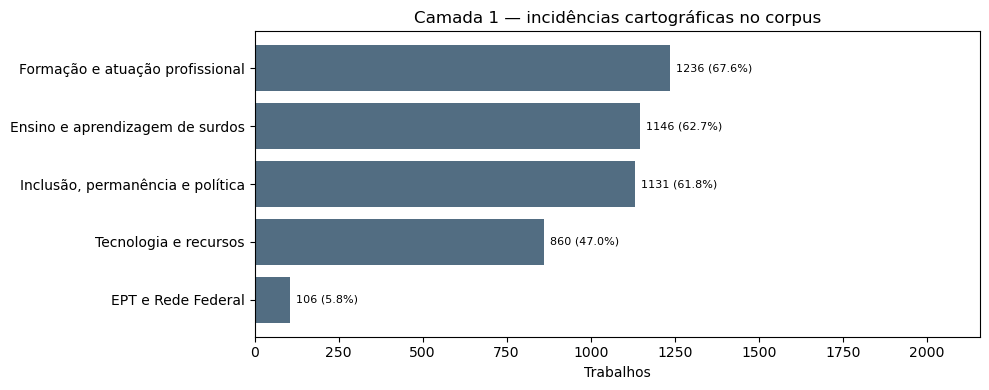

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(quadro["Eixo cartográfico"], quadro["Incidências"], color="#526D82")
ax.invert_yaxis()
for i, (_, l) in enumerate(quadro.iterrows()):
    ax.text(l["Incidências"] + len(corpus) * 0.01, i, f"{l['Incidências']} ({l['% do corpus']}%)",
            va="center", fontsize=8)
ax.set_title("Camada 1: incidências cartográficas no corpus")
ax.set_xlabel("Trabalhos"); ax.set_xlim(0, len(corpus) * 1.18)
plt.tight_layout(); plt.show()

In [10]:
quadro_dim = (proximidade.sum().rename_axis("Dimensão do objeto").reset_index(name="Trabalhos")
              .assign(**{"% do corpus": lambda q: (q["Trabalhos"] / len(corpus) * 100).round(1)})
              .sort_values("Trabalhos", ascending=False))
display(quadro_dim)

estratos = (corpus["dimensoes_atendidas"].value_counts().sort_index()
            .rename_axis("Dimensões reunidas").reset_index(name="Trabalhos"))
display(Markdown("**Estratificação do corpus por aderência ao objeto.**"))
display(estratos)

nucleo = corpus[corpus["dimensoes_atendidas"] >= 3]
contraste = corpus[corpus["dimensoes_atendidas"] == 2]
display(Markdown(
    f"Candidatos ao núcleo de leitura integral, com três ou mais dimensões: **{len(nucleo)}**. "
    f"Camada de contraste, com duas dimensões: **{len(contraste)}**. "
    f"Nenhum trabalho do corpus reúne as cinco dimensões."
))
display(nucleo[["identificador", "titulo_completo", "autores", "ano_defesa",
                "instituicao_origem", "dimensoes_atendidas"]]
        .sort_values("dimensoes_atendidas", ascending=False))

,Dimensão do objeto,Trabalhos,% do corpus
0,Mediação conceitual,257,14.1
3,Registro bilíngue,182,10.0
1,Planejamento conjunto,165,9.0
4,EPT,106,5.8
2,Condições institucionais,62,3.4


**Estratificação do corpus por aderência ao objeto.**

,Dimensões reunidas,Trabalhos
0,0,1251
1,1,410
2,2,145
3,3,20
4,4,3


Candidatos ao núcleo de leitura integral, com três ou mais dimensões: **23**. Camada de contraste, com duas dimensões: **145**. Nenhum trabalho do corpus reúne as cinco dimensões.

,identificador,titulo_completo,autores,ano_defesa,instituicao_origem,dimensoes_atendidas
185,14637311,A ATUAÇÃO DO TRADUTOR-INTÉRPRETE DE LÍNGUA DE SINAIS/ PORTUGUÊS (TILSP) NO INSTITUTO FEDERAL GOIANO: PERCE...,LEILA COUTINHO DIAS DA SILVA,2023,"INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA GOIANO",4
204,16527315,A INCLUSÃO DE SURDOS NO CAMPUS PELOTAS/IFSUL E A CRIAÇÃO DE UM SINALÁRIO DE LIBRAS PARA AUXILIAR NO PROCES...,TANIA REGINA SOUZA MADEIRA,2024,"INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA SUL-RIO-GRANDENSE",4
210,13886273,As bases conceituais da Educação Profissional e Tecnológica em Língua Brasileira de Sinais: o Padlet como ...,SABRINE DE OLIVEIRA,2023,"INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA DO RIO GRANDE DO SUL",4
13,14992760,"Uma análise fonológica para a escrita em SignWriting do léxico CASA, através da plataforma SignPuddle: um ...",CRISIANE DE FREITAS SOARES,2022,UNIVERSIDADE FEDERAL DE SANTA CATARINA,3
262,9810649,INTERLIB: ferramenta colaborativa para tradutores e intérpretes de Libras.,RALFH ALAN GOMES MACHADO,2020,UNIVERSIDADE FEDERAL DO PARÁ,3
903,12062801,COMUNICAÇÃO PELA LÍNGUA BRASILEIRA DE SINAIS NO CUIDADO A CRIANÇA COM DEFICIÊNCIA AUDITIVA: UMA PROPOSTA D...,DOMISY DE ARAUJO VIEIRA,2022,UNIVERSIDADE FEDERAL FLUMINENSE,3
873,16090920,DA LIBRAS ESCRITA À ESCRITA EM LÍNGUA PORTUGUESA: UMA PROPOSTA DIDÁTICO-PEDAGÓGICA PARA APERFEIÇOAR A ESCR...,IARA MIKAL HOLLAND OLIZAROSKI,2024,UNIVERSIDADE ESTADUAL DO OESTE DO PARANÁ,3
390,13517934,Modelagem de um Sinalário em LIBRAS para estudantes do ensino profissional tecnológico com deficiência aud...,MARCOS CESAR DOMINGOS FERREIRA,2022,UNIVERSIDADE DO ESTADO DA BAHIA,3
352,13303728,"EXPERIÊNCIA COLABORATIVA ENTRE PROFESSOR SURDO, INTÉRPRETE E PROFESSOR OUVINTE NO PLANEJAMENTO DE UM CURSO...",CASSIA MICHELE VIRGINIO DA SILVA,2022,FUNDAÇÃO UNIVERSIDADE FEDERAL DO PAMPA,3
316,12810290,Produção de sinalário em LIBRAS para equipamentos laboratoriais utilizados no Ensino Tecnológico na área d...,ROGERIO PACHECO RODRIGUES,2022,UNIVERSIDADE FEDERAL DE UBERLÂNDIA,3


### Composição do núcleo de leitura

A estratificação por dimensões **indica** candidatos; ela não compõe o núcleo. A composição
abaixo resulta de decisão de leitura, tomada sobre título, resumo e, quando disponível, o texto
integral. Registrá-la em separado preserva a distinção entre o que a regra alcança e o que o
julgamento acrescenta ou recusa.

Duas decisões merecem registro. **Lucineide Rodrigues da Silva (2023)** integra o núcleo com duas
dimensões porque o mapeamento conceitual colaborativo com suporte computacional não é alcançado
por nenhuma fonte da fundamentação teórica, e seu achado sobre a participação do intérprete no
planejamento sustenta passagem específica do projeto. **Domisy de Araújo Vieira (2022)** integra
o núcleo embora situada na enfermagem e fora da Educação Profissional e Tecnológica.

Sete trabalhos indicados pela regra não foram incorporados: aqueles cujo objeto a fundamentação
teórica já sustenta, como fonologia e escrita de sinais e subjetividades do intérprete, e aqueles que
se afastam do recorte, como a escrita da língua portuguesa como segunda língua, a acessibilidade
do processo de inscrição e a escolarização de estudantes com deficiência intelectual.

A leitura integral é a única base admissível para o contraste qualitativo (seção 1). O número de
dimensões reunidas descreve a aderência textual de cada trabalho, e não sua importância para a
argumentação: obras de duas dimensões podem sustentar o contraste melhor do que outras de três,
conforme o que a leitura revelar.

In [11]:
# Núcleo de leitura integral, na ordem em que os documentos estão arquivados.
# A regra indica candidatos; esta relação resulta de decisão de leitura registrada.
NUCLEO_DE_LEITURA = [
    # Ordem de prioridade de leitura, idêntica à numeração dos arquivos na
    # pasta Leituras Obrigatórias. Critério: dimensões reunidas em ordem
    # decrescente e, no empate, planejamento conjunto, EPT, mediação
    # conceitual e ano de defesa mais recente.
    "16527315",  # 01. Tania Regina Souza Madeira (2024)
    "13886273",  # 02. Sabrine de Oliveira (2023)
    "14637311",  # 03. Leila Coutinho Dias da Silva (2023)
    "bdtd_search_0025",  # 04. Graziela Jane Bergamin (2023)
    "13595595",  # 05. Ana Abadia dos Santos Mendonça (2022)
    "bdtd_search_0064",  # 06. Jackeline Mendes de Souza (2022)
    "11199216",  # 07. Ermans Quintela Carvalho (2021)
    "13303728",  # 08. Cassia Michele Virginio da Silva (2022)
    "11185256",  # 09. Margarida Maria Pimentel de Souza (2021)
    "9810649",  # 10. Ralfh Alan Gomes Machado (2020)
    "16426070",  # 11. Aline de Jesus Santana (2024)
    "15652935",  # 12. Daniel Souza Cesar (2024)
    "14212041",  # 13. Erliandro Felix Silva (2023)
    "12810290",  # 14. Rogério Pacheco Rodrigues (2022)
    "13517934",  # 15. Marcos César Domingos Ferreira (2022)
    "11447421",  # 16. Márcia José Pedro Guardia (2021)
    "IFPE_cb3b8e9bec1489855d24e87895fe77d6",  # 17. Lúcio Costa de Andrade (2024)
    "15453655",  # 18. Adriano Brito Feitoza (2024)
    "14796815",  # 19. Lucineide Rodrigues da Silva (2023)
    "16756261",  # 20. Ana Carolina Raimundo Silva (2024)
    "14623701",  # 21. Karina Vaneska Pereira de Carvalho (2023)
    "11036277",  # 22. Gabriella da Costa Pinheiro (2021)
]

nucleo_lido = corpus[corpus["identificador"].astype(str).isin(NUCLEO_DE_LEITURA)].copy()
indicados = set(corpus.loc[corpus["dimensoes_atendidas"] >= 3, "identificador"].astype(str))
escolhidos = set(NUCLEO_DE_LEITURA)

resumo_nucleo = pd.DataFrame([
    {"Situação": "Indicados pela regra e incorporados", "Trabalhos": len(indicados & escolhidos)},
    {"Situação": "Indicados pela regra e não incorporados", "Trabalhos": len(indicados - escolhidos)},
    {"Situação": "Incorporados por decisão de leitura, abaixo do corte", "Trabalhos": len(escolhidos - indicados)},
])
display(resumo_nucleo)
assert len(escolhidos) == len(NUCLEO_DE_LEITURA), "identificadores repetidos no núcleo"
assert escolhidos <= set(corpus["identificador"].astype(str)), "há trabalho do núcleo fora do corpus"

display(Markdown(
    f"Núcleo de leitura integral: **{len(nucleo_lido)}** trabalhos, de um corpus de **{len(corpus)}**. "
    f"Distribuição por dimensões reunidas: "
    + " · ".join(f"**{k}** dimensões: {v}" for k, v in
                 sorted(nucleo_lido["dimensoes_atendidas"].value_counts().items(), reverse=True))
    + "."
))
display(nucleo_lido[["identificador", "autores", "ano_defesa", "titulo_completo",
                     "dimensoes_atendidas"]].sort_values("dimensoes_atendidas", ascending=False))

,Situação,Trabalhos
0,Indicados pela regra e incorporados,16
1,Indicados pela regra e não incorporados,7
2,"Incorporados por decisão de leitura, abaixo do corte",6


Núcleo de leitura integral: **22** trabalhos, de um corpus de **1829**. Distribuição por dimensões reunidas: **4** dimensões: 3 · **3** dimensões: 13 · **2** dimensões: 5 · **1** dimensões: 1.

,identificador,autores,ano_defesa,titulo_completo,dimensoes_atendidas
185,14637311,LEILA COUTINHO DIAS DA SILVA,2023,A ATUAÇÃO DO TRADUTOR-INTÉRPRETE DE LÍNGUA DE SINAIS/ PORTUGUÊS (TILSP) NO INSTITUTO FEDERAL GOIANO: PERCE...,4
204,16527315,TANIA REGINA SOUZA MADEIRA,2024,A INCLUSÃO DE SURDOS NO CAMPUS PELOTAS/IFSUL E A CRIAÇÃO DE UM SINALÁRIO DE LIBRAS PARA AUXILIAR NO PROCES...,4
210,13886273,SABRINE DE OLIVEIRA,2023,As bases conceituais da Educação Profissional e Tecnológica em Língua Brasileira de Sinais: o Padlet como ...,4
232,bdtd_search_0025,"Bergamin, Graziela Jane",2023,EDUCAÇÃO ESPECIAL NA PERSPECTIVA INCLUSIVA E PRÁTICAS DOCENTES NO INSTITUTO FEDERAL DO ESPÍRITO SANTO: a c...,3
262,9810649,RALFH ALAN GOMES MACHADO,2020,INTERLIB: ferramenta colaborativa para tradutores e intérpretes de Libras.,3
390,13517934,MARCOS CESAR DOMINGOS FERREIRA,2022,Modelagem de um Sinalário em LIBRAS para estudantes do ensino profissional tecnológico com deficiência aud...,3
352,13303728,CASSIA MICHELE VIRGINIO DA SILVA,2022,"EXPERIÊNCIA COLABORATIVA ENTRE PROFESSOR SURDO, INTÉRPRETE E PROFESSOR OUVINTE NO PLANEJAMENTO DE UM CURSO...",3
316,12810290,ROGERIO PACHECO RODRIGUES,2022,Produção de sinalário em LIBRAS para equipamentos laboratoriais utilizados no Ensino Tecnológico na área d...,3
313,11185256,MARGARIDA MARIA PIMENTEL DE SOUZA,2021,GLOSSÁRIOS ILUSTRADOS BILÍNGUES (LIBRAS-PORTUGUÊS): POR UMA PEDAGOGIA LEXICOTERMINOLÓGICO-FUNCIONAL,3
310,11447421,MARCIA JOSE PEDRO GUARDIA,2021,MATERIAL DIDÁTICO TÁTIL À TECNOLOGIA DIGITAL – A ATENÇÃO E O ENSINO DE MATRIZES A ESTUDANTES SURDOS: uma e...,3


## 6 Descrição do corpus

As distribuições a seguir situam a produção reunida quanto a origem, tipo documental, período e
instituição. Descrevem o campo delimitado e não medem, por si, aproximação com o objeto desta
pesquisa: campo preenchido não equivale a leitura realizada, e a força de cada evidência depende
do conteúdo efetivamente consultado.

,Base de origem,Trabalhos
0,Catálogo de Teses CAPES,1184
1,BDTD (IBICT),452
2,Catálogo de Teses CAPES | BDTD (IBICT),174
3,BDTD (IBICT) | Catálogo de Teses CAPES,19


,Tipo documental,Trabalhos
0,Dissertação,1414
1,Tese,415


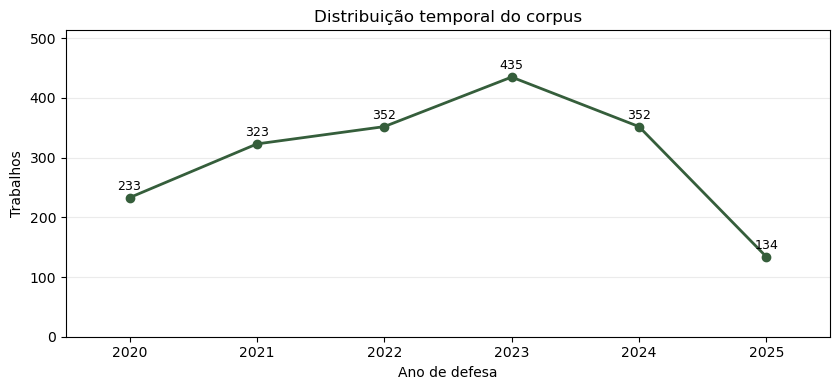

**Instituições com maior número de trabalhos no corpus.**

,Instituição,Trabalhos
0,UNIVERSIDADE FEDERAL DE SANTA CATARINA,75
1,UNIVERSIDADE DE BRASÍLIA,45
2,UNIVERSIDADE FEDERAL FLUMINENSE,36
3,UNIVERSIDADE FEDERAL DE MINAS GERAIS,32
4,UNIVERSIDADE FEDERAL DE GOIÁS,31
5,UNIVERSIDADE FEDERAL DE SÃO CARLOS,31
6,INSTITUTO NACIONAL DE EDUCAÇÃO DE SURDOS,30
7,UNIVERSIDADE FEDERAL DO RIO GRANDE DO NORTE,30
8,Universidade Federal de Santa Catarina (UFSC),29
9,UNIVERSIDADE FEDERAL DE ALAGOAS,28


In [12]:
display(corpus["fonte_original"].value_counts().rename_axis("Base de origem").reset_index(name="Trabalhos"))
display(corpus["tipo_documental"].value_counts().rename_axis("Tipo documental").reset_index(name="Trabalhos"))

por_ano = (pd.to_numeric(corpus["ano_defesa"], errors="coerce").value_counts()
           .sort_index().rename_axis("Ano de defesa").reset_index(name="Trabalhos"))
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(por_ano["Ano de defesa"], por_ano["Trabalhos"], marker="o", color="#355E3B", linewidth=2)
for _, l in por_ano.iterrows():
    ax.text(l["Ano de defesa"], l["Trabalhos"] + por_ano["Trabalhos"].max() * 0.03,
            str(int(l["Trabalhos"])), ha="center", fontsize=9)
ax.set_title("Distribuição temporal do corpus")
ax.set_xlabel("Ano de defesa"); ax.set_ylabel("Trabalhos")
ax.set_xlim(ANO_INICIAL - 0.5, ANO_FINAL + 0.5)
ax.set_ylim(0, por_ano["Trabalhos"].max() * 1.18)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.show()

display(Markdown("**Instituições com maior número de trabalhos no corpus.**"))
display(corpus["instituicao_origem"].value_counts().head(12)
        .rename_axis("Instituição").reset_index(name="Trabalhos"))

In [13]:
# Localização dos documentos: condição para a leitura dirigida do núcleo analítico.
acesso = pd.DataFrame({
    "Situação": ["Endereço de repositório registrado", "Arquivo local disponível"],
    "Trabalhos": [int(corpus["link_repositorio"].notna().sum()), int(corpus["arquivo_local"].notna().sum())],
})
acesso["% do corpus"] = (acesso["Trabalhos"] / len(corpus) * 100).round(1)
display(acesso)

,Situação,Trabalhos,% do corpus
0,Endereço de repositório registrado,1829,100.0
1,Arquivo local disponível,449,24.5


## 7 Validação da regra de triagem

A regra de termos é um instrumento de triagem e, como tal, produz erro. O que sustenta seu
emprego não é a automação, e sim a medição desse erro. Adota-se, para tanto, a conferência
manual de uma amostra aleatória com semente fixa, o que a torna reproduzível por terceiros.

A amostra é extraída do conjunto de registros que satisfazem os critérios C3 a C5, incluindo
tanto os selecionados quanto os excluídos por C6, de modo que se possam observar as duas formas
de erro: a inclusão de trabalhos alheios ao campo e a exclusão de trabalhos que a ele pertencem.
Para cada registro sorteado, a conferência examina título, palavras-chave e resumo e registra se
a decisão binária da regra procede. A classificação por eixos não integra esta conferência,
pois exigiria outro instrumento e outra pergunta de validação. Portanto, a medida desta seção
cobre exclusivamente C6; C3 a C5 são conferidos diretamente pelas contagens e pelos invariantes
do funil e não integram a estimativa de acerto.

A conferência é registrada em coluna própria da planilha de trabalho, sob o nome
`validacao_manual`, com os valores `procede` e `nao_procede`. Enquanto essa coluna não existir, o
caderno assinala a validação como pendente. Concluída a conferência, são reportados o acerto
global da regra, seu intervalo de Wilson e a relação dos casos discordantes; quando um padrão
de erro se repetir, a regra é ajustada de modo declarado e submetida a nova amostra independente.

A conferência é realizada por avaliador único, o próprio pesquisador, que é também quem formulou
a regra. A medida reportada é, portanto, a taxa de acerto da regra frente a essa leitura, e não
concordância entre avaliadores independentes; o padrão de referência e o instrumento avaliado
compartilham o mesmo julgamento, limite que se declara em vez de se contornar.

Não se recorre ao cálculo de concordância entre codificadores como prova de validade da análise
qualitativa posterior, pela mesma razão exposta na seção 4.4 do projeto: a interpretação do
pesquisador é reconhecida como parte constitutiva da análise. A medida aqui reportada diz
respeito exclusivamente ao desempenho da regra de triagem, e não à interpretação dos trabalhos.

In [14]:
elegiveis = dados[metadados_minimos & no_periodo & tipo_elegivel].copy()
# A validação mede C6 antes do descarte manual; o descarte é a consequência documentada
# da conferência e não pode reescrever retroativamente a decisão avaliada.
elegiveis["decisao_da_regra"] = pertinente.loc[elegiveis.index]
amostra = elegiveis.sample(n=min(TAMANHO_DA_AMOSTRA, len(elegiveis)), random_state=SEMENTE)

if "validacao_manual" in dados.columns:
    conferidos = amostra[amostra["validacao_manual"].notna()]
    if len(conferidos):
        valores = conferidos["validacao_manual"].str.strip().str.lower()
        assert set(valores) <= {"procede", "nao_procede"}, "valor inválido em validacao_manual"
        procede = valores.eq("procede")
        p = procede.mean()
        # Intervalo de Wilson. A aproximação normal, usada antes, produz limite
        # superior acima de 100% quando a proporção se aproxima de 1 e exige
        # truncamento artificial; Wilson permanece dentro de [0, 1] por construção.
        n_conf = len(conferidos)
        z = 1.959963984540054
        denominador = 1 + z**2 / n_conf
        centro = (p + z**2 / (2 * n_conf)) / denominador
        meia = z / denominador * (p * (1 - p) / n_conf + z**2 / (4 * n_conf**2)) ** 0.5
        li, ls = centro - meia, centro + meia
        assert 0 <= li <= p <= ls <= 1, "intervalo de Wilson fora de [0, 1]"
        display(Markdown(
            f"Amostra conferida: **{n_conf}** de {len(amostra)} registros sorteados. "
            f"Acerto da regra frente à conferência manual: **{p * 100:.1f}%** "
            f"(intervalo de Wilson de 95%: {li * 100:.1f}% a {ls * 100:.1f}%). "
            "A conferência é de avaliador único, o próprio pesquisador, de modo que a "
            "medida expressa a correspondência entre a regra declarada e a leitura de "
            "quem a formulou, e não concordância entre avaliadores independentes."
        ))
        display(conferidos.loc[~procede, ["identificador", "titulo_completo", "decisao_da_regra"]])
    else:
        display(Markdown("Coluna `validacao_manual` presente, porém ainda sem registros conferidos."))
else:
    display(Markdown(
        f"**Validação pendente.** A amostra de **{len(amostra)}** registros está reproduzida "
        f"abaixo (semente `{SEMENTE}`). Para registrá-la, acrescente a coluna `validacao_manual` "
        f"à planilha de trabalho, com os valores `procede` ou `nao_procede`."
    ))
    display(amostra[["identificador", "titulo_completo", "ano_defesa", "decisao_da_regra"]])

Amostra conferida: **120** de 120 registros sorteados. Concordância com a regra: **97.5%** (intervalo de 95%: 94.7% a 100.0%).

,identificador,titulo_completo,decisao_da_regra
1176,11676593,ANÁLISE DO DESENVOLVIMENTO DE HABILIDADES COMUNICATIVAS DE UMA CRIANÇA AUTISTA E FILHA DE PAIS SURDOS,True
1857,11082210,AMBIENTALIZAÇÃO CURRICULAR NOS CURSOS DE LICENCIATURA DA UNIVERSIDADE FEDERAL DE RONDÔNIA - UNIR: UMA ANÁL...,True
947,11467001,"MALFORMAÇÕES CONGÊNITAS E CÂNCERES DE BEXIGA, PULMÃO E BRÔNQUIOS ASSOCIADOS À EXPOSIÇÃO AO TABACO NA POPUL...",True


## 8 Estatuto probatório dos campos

O quadro abaixo declara, para cada campo mobilizado, como foi obtido e o que autoriza afirmar.
A distinção entre campo derivado por regra e campo decidido por leitura é o que permite situar
cada afirmação do levantamento em um dos três níveis de sustentação enunciados na seção 1.

| Campo | Como foi obtido | O que sustenta |
| --- | --- | --- |
| `ano_defesa`, `tipo_documental`, `instituicao_origem`, `fonte_original` | Metadado bibliográfico das bases | Descrição de autoria, ano, instituição e origem |
| `eixos_tematicos` | Regra de termos declarada sobre título, palavras-chave e resumo | Incidência cartográfica. Não sustenta afirmação sobre o conteúdo do trabalho |
| `dimensoes_atendidas` | Contagem das dimensões da hipótese analítica alcançadas pela mesma regra | Indicação de aderência ao objeto. Não substitui a leitura, que confirma ou recusa a indicação |
| Pertencimento ao corpus | Regra declarada (C1 a C6) | Composição do corpus cartográfico |
| Descarte por leitura | Decisão individual registrada, com justificativa | Exclusão de registro cuja evidência textual se mostrou enganosa |
| Classificação da contribuição | Decisão registrada, apenas para trabalhos lidos integralmente | Relação de cada trabalho com a lacuna investigada |
| `link_repositorio`, `arquivo_local` | Endereço conferido do documento | Condição de acesso para a leitura dirigida |

## 9 Limites do levantamento

A delimitação a teses e dissertações nacionais exclui artigos, literatura internacional e
repositórios não indexados, que podem conter configurações relevantes ao problema. A busca em
BDTD/IBICT e no Catálogo da CAPES não é exaustiva em relação à produção científica brasileira, e
as estratégias de busca originais não foram integralmente preservadas, tendo sido reconstruídas
como protocolo de transparência e não como transcrição literal das consultas.

A triagem apoia-se em título, palavras-chave e resumo. Registros cujos resumos estejam ausentes
ou sejam pouco informativos ficam sub-representados, e trabalhos que tratem do tema sem empregar
os termos declarados não são alcançados pela regra. A conferência por amostra mede a extensão
desse erro, mas não o elimina. No corpus final, 31 registros (1,7%) têm menos de 300 caracteres
somados nesses três campos. Quatro têm menos de 150: `14457847` (127), `13600911` (92),
`15407383` (149) e `bdtd_000236` (135). Esses casos exigem cautela reforçada na interpretação
de qualquer classificação automática.

Os quantitativos descrevem a distribuição da produção no campo delimitado e não autorizam
afirmar ausência absoluta de pesquisas fora desse recorte. A caracterização da lacuna depende do
contraste qualitativo entre contexto, participantes, unidade de análise, conceito técnico
central, registro em Libras, momento de uso, produto e forma de avaliação, e apoia-se na leitura
dirigida do núcleo de maior aderência, não na incidência de termos.

A triagem foi conduzida por um único pesquisador, o que recomenda prudência na generalização e
torna aconselhável a discussão de casos limítrofes com a orientação.

## 10 Declaração de método

A triagem temática dos registros foi realizada por regra de termos declarada, aplicada por
script determinístico sobre título, palavras-chave e resumo, a partir do arquivo bruto
preservado. Os critérios de inclusão, os termos que operacionalizam cada eixo e o código que os
aplica estão integralmente registrados neste caderno e podem ser reexecutados por terceiros
sobre a mesma fonte, com resultados idênticos.

A regra é submetida a validação por amostra aleatória de semente fixa, conferida manualmente,
cujo percentual de concordância e cujos casos discordantes são relatados na seção 7. Os ajustes
eventualmente decorrentes dessa conferência são declarados e seguidos de nova amostra
independente.

A leitura integral aplica-se ao núcleo analítico de maior aderência ao objeto. Os fichamentos
individuais estão registrados para parte desse núcleo e em elaboração para os demais; até sua
conclusão, as obras sem fichamento sustentam-se no resumo integral, sem citação com página. As
decisões qualitativas, isto é, a classificação da contribuição, a matriz de
contraste e a formulação da lacuna, apoiam-se nessa leitura, e não na triagem automatizada, e
permanecem sob responsabilidade do autor, nos termos da declaração de uso de inteligência
artificial que integra o projeto de pesquisa.